In [1]:
# Gõ dòng này vào cell đầu tiên và bấm Run (Shift + Enter) or Run All
get_ipython().run_line_magic('run', '../_setup.py')

In [2]:
from functools import partial, reduce

import statsmodels.api as sm
from matplotlib.ticker import MaxNLocator
from prophet import Prophet
from statsforecast import StatsForecast
from statsforecast.adapters.prophet import AutoARIMAProphet
from statsforecast.models import MSTL, AutoETS, AutoARIMA, ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.api import VAR
from utilsforecast.evaluation import evaluate
from utilsforecast.feature_engineering import trend, fourier, pipeline
from utilsforecast.losses import rmse, mae, mape, mase
from utilsforecast.preprocessing import fill_gaps

Importing plotly failed. Interactive plots will not work.


In [3]:
BASE_DIR = Path.cwd().parent.parent
DATA_DIR = BASE_DIR / "data"
print(DATA_DIR)

/home/phu/Documents/GitHub/-Time-Series-Analysis-and-Forecasting-methods-/data


# Advanced forecasting methods 

In this chapter, we briefly discuss four more advanced forecasting methods that build on the models discussed in earlier chapters.

## 12.1 Complex seasonality

So far, we have mostly considered relatively simple seasonal patterns such as quarterly and monthly data. However, higher frequency time series often exhibit more complicated seasonal patterns. For example, daily data may have a weekly pattern as well as an annual pattern. Hourly data usually has three types of seasonality: a daily pattern, a weekly pattern, and an annual pattern. Even weekly data can be challenging to forecast as there are not a whole number of weeks in a year, so the annual pattern has a seasonal period of $365.25/7 \approx 52.179$ on average. 



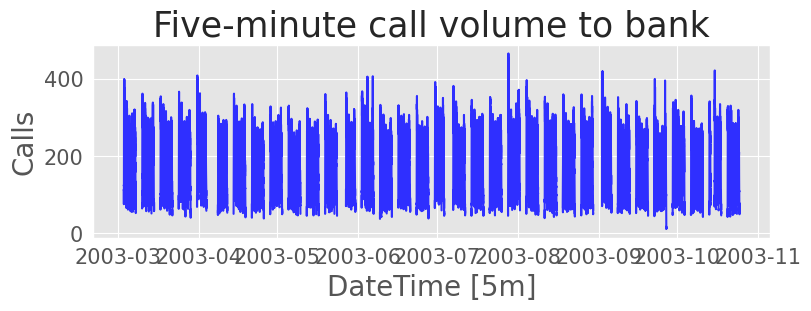

In [4]:
bank_calls = (
    pd.read_csv(DATA_DIR / "bank_calls.csv", parse_dates=["ds"])
    .loc[lambda x: x["y"] > 0]
)
bank_calls_5min = fill_gaps(bank_calls, freq="5min")
fig, ax = plt.subplots(figsize=(8, 3))
plot_series(
    bank_calls_5min,
    xlabel="DateTime [5m]", ylabel="Calls",
    title="Five-minute call volume to bank",
    ax=ax,
)

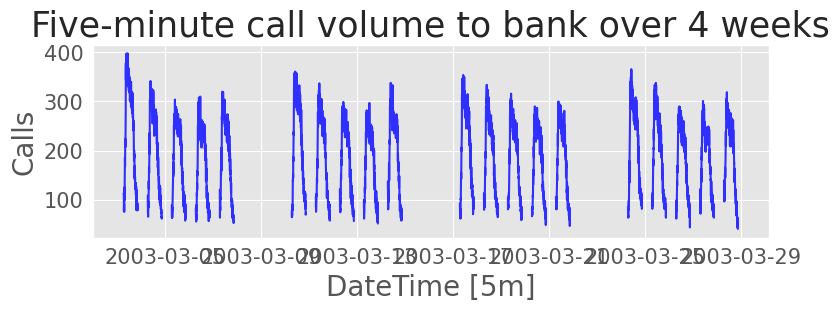

In [5]:
df = bank_calls_5min.loc[lambda x: x["ds"] <= "2003-03-29"]
fig, ax = plt.subplots(figsize=(8, 3))
plot_series(df, xlabel="DateTime [5m]", ylabel="Calls",
    title="Five-minute call volume to bank over 4 weeks",
    ax=ax,
)

## MSTL with multiple seasonal periods 

The `MSTL()` function is designed to deal with multiple seasonalities, and it can be used to decompose a series into its trend, multiple seasonal, and remainder components.

In [6]:
model = MSTL(season_length=[169, 169 * 5])
sf = StatsForecast(models=[model], freq="5min")
sf = sf.fit(bank_calls.assign(y = lambda df: np.sqrt(df["y"])))
dcmp = sf.fitted_[0, 0].model_

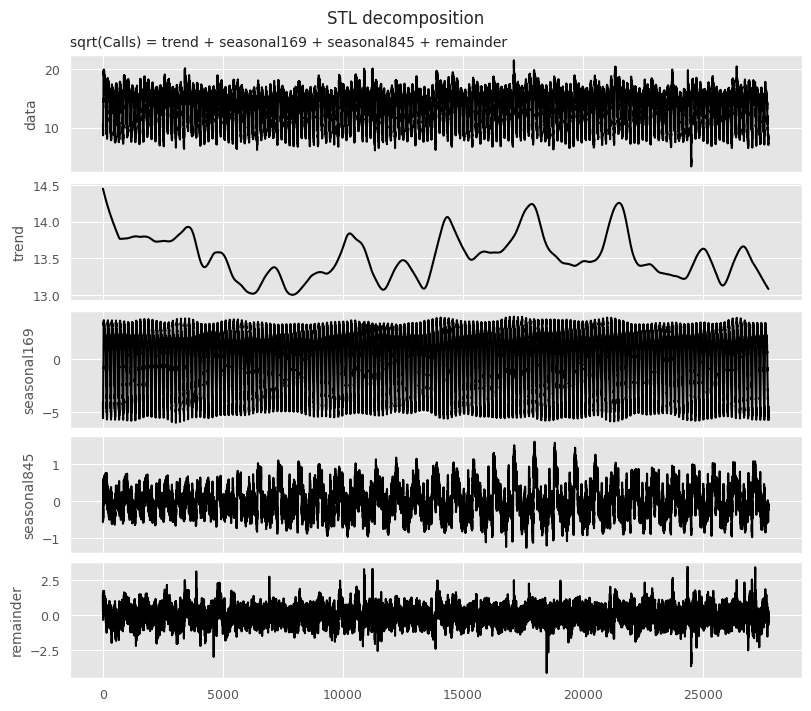

In [7]:
fig, axes = plt.subplots(5, figsize=(8, 7), sharex=True)
for (ax, column) in zip(axes, dcmp.columns):
    sns.lineplot(data=dcmp, x=dcmp.index, y=column, ax=ax, color="k")
axes[0].set_title(
    "sqrt(Calls) = trend + seasonal169 + seasonal845 + remainder",
    size="medium", loc="left")
axes[-1].set(xlabel="")
fig.suptitle("STL decomposition")
plt.show()

There are two seasonal patterns shown in Figure 12.3, one for the time of day (the third panel), and one for the time of week (the fourth panel). Note that in this case, there is little trend seen in the data, and the weekly seasonality is weak.

The decomposition can also be used in forecasting, with each of the seasonal components forecast using a `Seasonal Naïve` method, and the seasonally adjusted data forecast using `ETS`.

In [8]:
# Find forecast timestamps: weekdays 7am to 9pm
start = bank_calls["ds"].max() + pd.offsets.Minute(5)
all_5min = pd.date_range(start, start + pd.offsets.Day(7), freq="5min")
fc_ds = all_5min.to_series().loc[lambda x: (
    x.dt.weekday.between(0, 4)
    & x.dt.strftime("%H:%M").between("07:00", "21:00")
)]

# Forecast, back-transform numerical results, and set ds with gaps
fc = sf.predict(h=len(fc_ds), level=[80, 95])
res = fc.select_dtypes(include=np.number)
fc = (
    fc.assign(**res.transform(lambda x: x**2))
    .assign(ds=fc_ds.to_numpy())
    .pipe(fill_gaps, freq="5min")
)

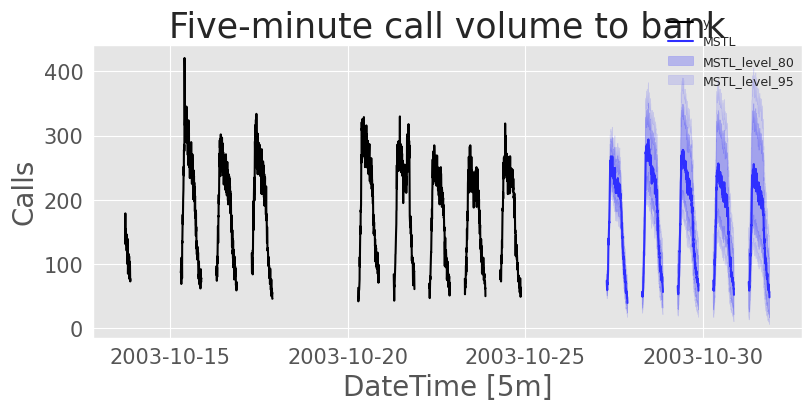

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_series(bank_calls_5min, fc, level=[80, 95],
    max_insample_length=169 * (14 + 5),
    xlabel="DateTime [5m]", ylabel="Calls",
    title="Five-minute call volume to bank",
    palette="black_and_blue", rm_legend=False, ax=ax)
ax.xaxis.set_major_locator(MaxNLocator(4))
fig